In [1]:
import numpy as np
from astropy.io import ascii as asc
import matplotlib.pyplot as plt
from fleck import Star
import fleck

In [2]:
## -- load LCO data
l = np.load('./data/lcogt/LCO_sinistro_data.npz')
t_jd_g = l['t_jd_g']
y_g = l['y_g']
yerr_g = l['yerr_g']

t_jd_r = l['t_jd_r']
y_r = l['y_r']
yerr_r = l['yerr_r']

t_g = t_jd_g - t_jd_r[0] # offset by start of r-band obs.
t_r = t_jd_r - t_jd_r[0] 

t2g = np.linspace(t_jd_g[0], t_jd_g[-1], 500) - t_jd_r[0] # filled-in time axes for nicer plotting
t2r = np.linspace(t_jd_r[0], t_jd_r[-1], 500) - t_jd_r[0]

In [3]:
Nvals = np.arange(1, 11, 1, dtype=int)
Nmax = Nvals[-1]
fits = np.zeros((len(Nvals), 3 * Nmax))

glcs = np.zeros((len(Nvals), len(t_g)))
rlcs = np.zeros((len(Nvals), len(t_r)))

glcs2 = np.zeros((len(Nvals), len(t2g)))
rlcs2 = np.zeros((len(Nvals), len(t2r)))

for i, N in enumerate(Nvals):
    path = './data/lcogt/modellc_N%d.npz' % (N)
    l = np.load(path)
    glcs[i] = np.copy(l['y_g'])
    rlcs[i] = np.copy(l['y_r'])

    glcs2[i] = np.copy(l['ylong_g'])
    rlcs2[i] = np.copy(l['ylong_r'])
    del l

l = np.load('./data/lcogt/modellc_N0.npz')
glc0 = l['y_g']
rlc0 = l['y_r']
del l


In [4]:
def computeChi2(ydata, yerr, modely):
    chi_array = ((ydata - modely) ** 2. / yerr ** 2.)
    return np.sum(chi_array)


gchi2vals = np.zeros((len(Nvals)))
rchi2vals = np.zeros((len(Nvals)))
gdofs = np.zeros((len(Nvals)))
rdofs = np.zeros((len(Nvals)))


for i, N in enumerate(Nvals): 
    gchi2vals[i] = computeChi2(y_g, yerr_g, glcs[i])
    gdofs[i] = len(y_g) - (N*3)
    rchi2vals[i] = computeChi2(y_r, yerr_r, rlcs[i])
    rdofs[i] = len(y_r) - (N*3)


gredchi2 = gchi2vals / gdofs
rredchi2 = rchi2vals / rdofs  

In [5]:
Prot = 2.97
tc_c = 60924.269172581
tc_b = 60929.002944444
tc_d = 60928.860150000

Jv1_start = 60924.08916926491
Jv1_end = 60924.45689687428
Jv2_start = 60928.680153672634
Jv2_end = 60929.13808086981

def phase_fold(t, y, period=Prot, t0=tc_c):
    phase = ((t - t0) % period) / period
    sort = np.argsort(phase)
    return phase[sort], y[sort]

phaseg, pfyg = phase_fold(t_g, y_g)
phaser, pfyr = phase_fold(t_r, y_r)

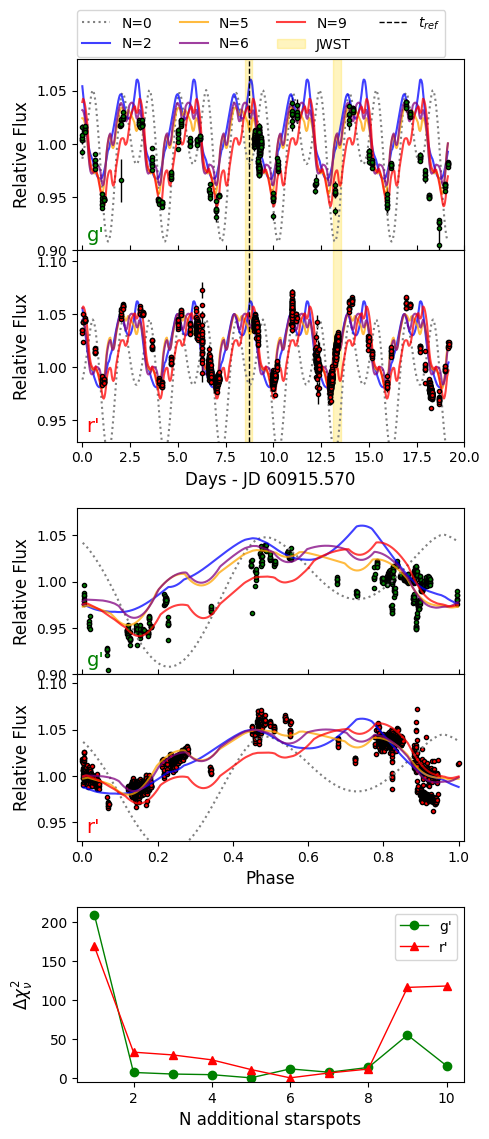

In [12]:
fig = plt.figure(figsize=(5, 11))
gs_lc    = fig.add_gridspec(2, 1, hspace=0., top=0.95, bottom=0.602)
gs_phase = fig.add_gridspec(2, 1, hspace=0., top=0.542, bottom=0.239)
gs_chi2  = fig.add_gridspec(1, 1, top=0.179, bottom=0.02)

ax0     = fig.add_subplot(gs_lc[0, 0])
ax1     = fig.add_subplot(gs_lc[1, 0], sharex=ax0)
ax_ph0  = fig.add_subplot(gs_phase[0, 0])
ax_ph1  = fig.add_subplot(gs_phase[1, 0], sharex=ax_ph0)
ax_chi2 = fig.add_subplot(gs_chi2[0, 0])

N_toinclude = np.array([2,5,6,9]) 
N_colors = np.array(['blue','orange','purple','red'])

# ---------- light curve ----------
ax0.errorbar(t_g, y_g, yerr_g, ls='None', marker='o', ms=3, c='black', mfc='green', lw=1)
ax0.tick_params(axis='x', which='both', direction='in')
ax1.errorbar(t_r, y_r, yerr_r, ls='None', marker='o', ms=3, c='black', mfc='red',   lw=1)

ax0.plot(t2g, glc0/np.nanmedian(glc0), ls='dotted', c='gray', label='N=0')
ax1.plot(t2r, rlc0/np.nanmedian(rlc0), ls='dotted', c='gray', label='N=0')
for ii, N in enumerate(N_toinclude):
    ax0.plot(t2g, glcs2[N-1]/np.nanmedian(glcs[N-1]), label='N=%d' % N, c=N_colors[ii], alpha=0.75)
    ax1.plot(t2r, rlcs2[N-1]/np.nanmedian(rlcs[N-1]), label='N=%d' % (N), c=N_colors[ii], alpha=0.75)

ax0.axvspan(Jv1_start-t_jd_r[0], Jv1_end-t_jd_r[0], fc='gold', ec='gold', zorder=1, alpha=0.25)
ax0.axvspan(Jv2_start-t_jd_r[0], Jv2_end-t_jd_r[0], fc='gold', ec='gold', zorder=1, alpha=0.25)
ax1.axvspan(Jv1_start-t_jd_r[0], Jv1_end-t_jd_r[0], fc='gold', ec='gold', zorder=1, alpha=0.25, label='JWST')
ax1.axvspan(Jv2_start-t_jd_r[0], Jv2_end-t_jd_r[0], fc='gold', ec='gold', zorder=1, alpha=0.25)
ax0.axvline(tc_c-t_jd_r[0], c='black', lw=1, ls='--', zorder=2)
ax1.axvline(tc_c-t_jd_r[0], c='black', lw=1, ls='--', zorder=2, label=r'$t_{ref}$')

ax0.text(0.025, 0.05, "g'", fontsize=14, c='green', transform=ax0.transAxes)
ax1.text(0.025, 0.05, "r'", fontsize=14, c='red',   transform=ax1.transAxes)
ax1.legend(loc=(0, 2.01), fontsize=10, ncol=4)

ax0.set_ylim(0.9,  1.08)
ax1.set_ylim(0.93, 1.11)
ax1.set_xlim(-0.3, 20.)
ax0.set_ylabel('Relative Flux', fontsize=12)
ax1.set_ylabel('Relative Flux', fontsize=12)
ax1.set_xlabel('Days - JD %.3f' % (t_jd_r[0]), fontsize=12)
ax0.tick_params(labelbottom=False)

# ---------- phase-folded ----------
ax_ph0.plot(phaseg, pfyg, ls='None', marker='o', ms=3, c='black', mfc='green', lw=1)
ax_ph0.tick_params(axis='x', which='both', direction='in')
ax_ph1.plot(phaser, pfyr, ls='None', marker='o', ms=3, c='black', mfc='red',   lw=1)

phase2g, pflc0g = phase_fold(t2g, (glc0/np.nanmedian(glc0)))
phase2r, pflc0r = phase_fold(t2r, (rlc0/np.nanmedian(rlc0)))
ax_ph0.plot(phase2g, pflc0g, ls='dotted', c='gray', label='N=0')
ax_ph1.plot(phase2r, pflc0r, ls='dotted', c='gray', label='N=0')
for ii, N in enumerate(N_toinclude):
    void, pflcig = phase_fold(t2g, glcs2[N-1]/np.nanmedian(glcs[N-1]))
    void, pflcir = phase_fold(t2r, rlcs2[N-1]/np.nanmedian(rlcs[N-1]))
    ax_ph0.plot(phase2g, pflcig, label='N=%d' % N, c=N_colors[ii], alpha=0.75)
    ax_ph1.plot(phase2r, pflcir, label='N=%d' % N, c=N_colors[ii], alpha=0.75)

ax_ph0.text(0.025, 0.05, "g'", fontsize=14, c='green', transform=ax_ph0.transAxes)
ax_ph1.text(0.025, 0.05, "r'", fontsize=14, c='red',   transform=ax_ph1.transAxes)

ax_ph0.set_ylim(0.9,  1.08)
ax_ph1.set_ylim(0.93, 1.11)
ax_ph1.set_xlim(-0.015, 1.015)
ax_ph0.set_ylabel('Relative Flux', fontsize=12)
ax_ph1.set_ylabel('Relative Flux', fontsize=12)
ax_ph1.set_xlabel('Phase', fontsize=12)
ax_ph0.tick_params(labelbottom=False)

# ---------- chi-squared ----------
ax_chi2.plot(Nvals, gredchi2-min(gredchi2), c='green', marker='o',  ms=6, lw=1, label="g'")
ax_chi2.plot(Nvals, rredchi2-min(rredchi2), c='red',   marker='^', ms=6, lw=1, label="r'")
ax_chi2.set_xlabel('N additional starspots', fontsize=12)
ax_chi2.set_ylabel(r'$\Delta \chi^2_\nu$', fontsize=12)
ax_chi2.legend(loc='best')
ax_chi2.set_ylim(-5,220)

plt.savefig('./figures/Figure7_lco_and_models_fits.pdf', dpi=600, bbox_inches='tight')
plt.show()